<a href="https://colab.research.google.com/github/ronnysadamhusen/heart-disease-digital-triage-assistant/blob/main/Project_MAI_22_Ronny_Sadam_Husen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Portofolio Proyek Machine Learning: Analisis Penyakit Jantung

**Oleh: Ronny Sadam Husen**

### Ringkasan Eksekutif
Proyek ini mendemonstrasikan alur kerja data science end-to-end untuk mendeteksi risiko penyakit jantung. Menggunakan teknik **Principal Component Analysis (PCA)** untuk efisiensi data dan algoritma **Decision Tree** untuk klasifikasi, sistem ini mampu memberikan prediksi kesehatan dengan tingkat akurasi yang tinggi.

**Tujuan Utama:**
1. Mengidentifikasi fitur kesehatan yang paling berpengaruh terhadap penyakit jantung.
2. Membangun model prediksi yang akurat dan mudah diinterpretasikan.

**Dataset:** [Heart Disease Dataset](https://storage.googleapis.com/dqlab-dataset/heart_disease.csv)

## Skenario Masalah: Tantangan di Klinik Kesehatan Modern

**Latar Belakang:**
> Klinik "Sehat Bersama" menghadapi lonjakan pasien yang ingin memeriksakan kesehatan jantung. Dengan keterbatasan jumlah dokter spesialis jantung dan alat diagnosa yang mahal, terjadi antrean panjang yang berisiko bagi pasien dalam kondisi kritis.

**Masalah Utama:**
> 1. **Waktu Tunggu:**
>> Diagnosa manual memerlukan waktu lama karena dokter harus meninjau belasan parameter kesehatan satu per satu.
> 2. **Skalabilitas:**
>> Klinik sulit melakukan screening awal secara masal kepada masyarakat dengan sumber daya yang ada saat ini.
> 3. **Resiko Human Error:**
>> Kelelahan tenaga medis dapat menyebabkan inkonsistensi dalam pembacaan data hasil lab yang kompleks.

**Solusi Proyek Ini:**
> Proyek ini membangun sistem **Asisten Diagnosa Digital** yang mampu melakukan penyaringan (*screening*) awal secara instan. Dengan mengolah data kesehatan pasien (usia, tekanan darah, kolesterol, dll.), model dapat memberikan indikasi risiko penyakit jantung dalam hitungan detik, sehingga dokter dapat memprioritaskan pasien yang membutuhkan penanganan segera (Triage).

## Framework Kerja: CRISP-DM

Untuk memastikan proyek ini memiliki standar profesional, alur kerja ini mengikuti metodologi **CRISP-DM**:

1.  **Business Understanding**:
> Memahami kebutuhan untuk deteksi dini risiko penyakit jantung secara otomatis.
2.  **Data Understanding**:
> Melakukan eksplorasi data (EDA) dan pengecekan korelasi antar fitur kesehatan.
3.  **Data Preparation**:
> Tahap pembersihan data, standarisasi, dan reduksi dimensi (PCA).
4.  **Modeling**:
> Melatih berbagai algoritma (Logistic Regression, Decision Tree, dll).
5.  **Evaluation**:
> Menentukan model terbaik berdasarkan akurasi, presisi, dan recall.
6.  **Deployment**:
> Implementasi model ke dalam fungsi prediksi untuk simulasi diagnosa pasien.

## 1. Persiapan Data (Loading & Pre-processing)

**Apa yang dilakukan?**
> Memuat pustaka Python (Pandas, Scikit-learn) dan menghubungkan dataset ke lingkungan kerja.

**Filosofi:**
> Ibarat ingin memasak hidangan bintang lima, kita harus memastikan semua bahan berkualitas sudah tersedia di meja sebelum mulai menyalakan kompor.

**Insight:**
> Data awal terdiri dari 14 parameter kesehatan seperti usia, tekanan darah, dan kadar kolesterol.

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
dataset_url = 'https://storage.googleapis.com/dqlab-dataset/heart_disease.csv'
heart_data = pd.read_csv(dataset_url)

# Menampilkan 5 baris pertama
display(heart_data.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 2. Pembersihan Data (Data Cleansing)

**Apa yang dilakukan?**
> Melakukan audit data untuk mencari nilai yang hilang (*missing values*) dan memastikan integritas data.

**Filosofi:**
> Kita membuang 'bahan yang busuk' agar tidak merusak seluruh rasa masakan. Data yang tidak lengkap dapat menyesatkan model dalam belajar.

**Insight:**
> Dataset ini memiliki kualitas yang sangat baik (tidak ditemukan nilai kosong), sehingga kita tetap memiliki 1025 sampel untuk dianalisis.

In [22]:
# Cek missing values
print("Jumlah missing values:")
print(heart_data.isnull().sum())

# Membersihkan data dengan menghapus baris yang kosong
heart_data_cleaned = heart_data.dropna()
print(f"\nUkuran data setelah pembersihan: {heart_data_cleaned.shape}")

Jumlah missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Ukuran data setelah pembersihan: (1025, 14)


## 3. Exploratory Data Analysis (EDA)

**Apa yang dilakukan?**
> Menganalisis distribusi statistik dan hubungan (korelasi) antar variabel menggunakan Heatmap.

**Filosofi:**
> Ini adalah tahap 'survei lapangan'. Kita memetakan siapa 'berteman' dengan siapa; misalnya, apakah usia berkorelasi linear dengan tekanan darah?

**Insight:**
> Melalui Heatmap, kita dapat melihat variabel mana yang memiliki ikatan kuat dengan 'Target' (status penyakit), memberikan petunjuk awal bagi model kita.

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


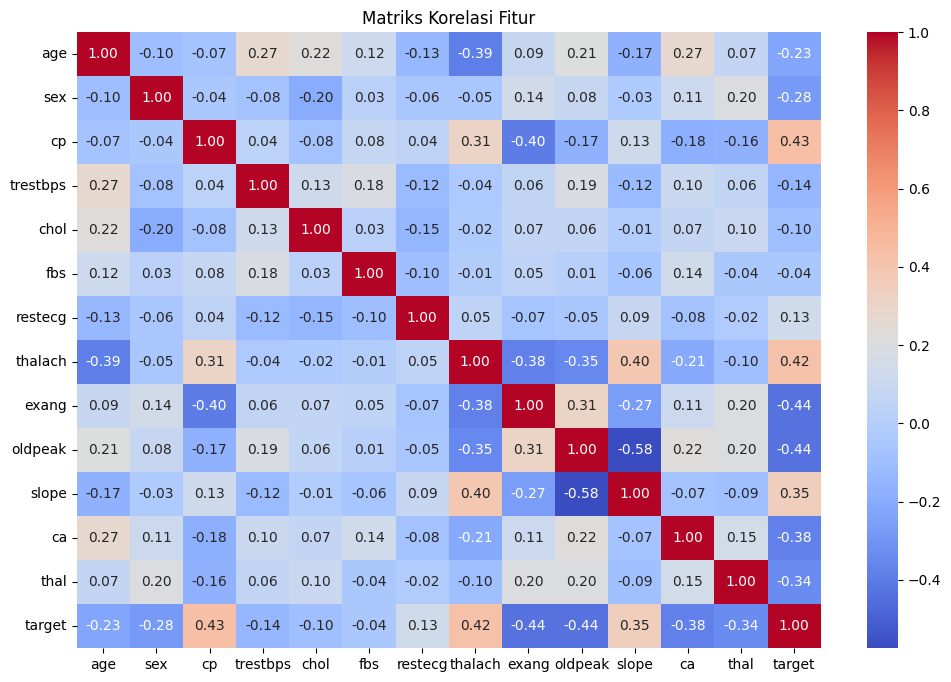

In [23]:
# Statistik Deskriptif
display(heart_data_cleaned.describe())

# Matriks Korelasi
plt.figure(figsize=(12, 8))
correlation_matrix = heart_data_cleaned.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Fitur')
plt.show()

**Mengapa Heatmap Ini Penting?**

**Apa yang harus dipahami dari output di atas?**
1.  **Kekuatan Hubungan (Korelasi):**
> Angka mendekati **1.0** atau **-1.0** menunjukkan hubungan yang sangat kuat. Misalnya, jika `thalach` (detak jantung maksimal) memiliki korelasi tinggi dengan `target`, itu berarti variabel tersebut adalah indikator kunci.
2.  **Arah Hubungan:**
    > *   **Positif (+):** Jika satu variabel naik, variabel lain ikut naik.
    > *   **Negatif (-):** Jika satu variabel naik, variabel lain turun (misal: semakin tua usia, terkadang detak jantung maksimal menurun).
3.  **Redundansi (Multikolinearitas):**
> Jika ada dua fitur yang korelasinya sangat tinggi satu sama lain (misal > 0.9), kita mungkin hanya butuh salah satunya saja agar model tidak 'bingung'.

**Pentingnya untuk Proyek:**
> Insight dari heatmap ini membantu kita melakukan **Feature Selection**. Kita jadi tahu fitur mana yang paling 'berjasa' dalam memprediksi penyakit jantung dan fitur mana yang mungkin bisa kita ringkas (menggunakan PCA nanti) tanpa kehilangan informasi penting.

## 4. Standarisasi & Reduksi Dimensi (PCA)

**Apa yang dilakukan?**
> Menyetarakan skala data dan menggunakan *Principal Component Analysis* (PCA) untuk merampingkan fitur.

**Filosofi:**
> Ibarat meringkas buku tebal menjadi poin-poin penting tanpa kehilangan inti ceritanya. Kita menggunakan Scree Plot sebagai panduan untuk menentukan berapa banyak 'poin penting' yang kita butuhkan.

**Insight:**
> Dengan 9 Komponen Utama (PC), kita berhasil mempertahankan mayoritas informasi penting sekaligus mengurangi kompleksitas data.

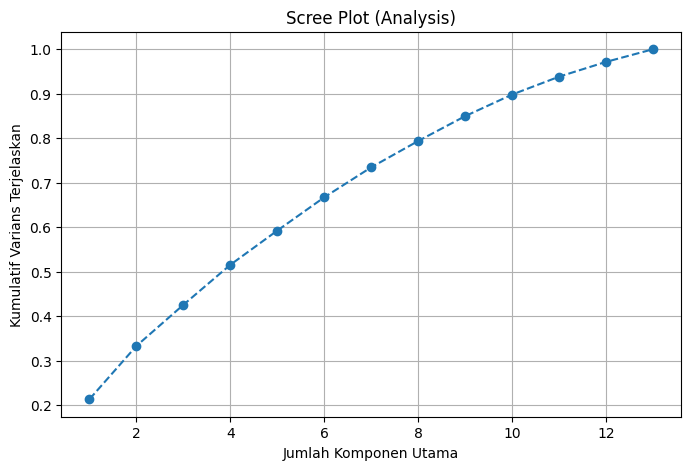

In [24]:
# Memisahkan fitur dan target
X = heart_data_cleaned.drop('target', axis=1)
y = heart_data_cleaned['target']

# Standarisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA untuk melihat varians
pca_full = PCA()
pca_full.fit(X_scaled)

# Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Jumlah Komponen Utama')
plt.ylabel('Kumulatif Varians Terjelaskan')
plt.title('Scree Plot (Analysis)')
plt.grid(True)
plt.show()

In [25]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

# Fit PCA jika diperlukan
pca_full = PCA()
pca_full.fit(X_scaled)

# Menghitung varians per komponen dan kumulatif
variances = pca_full.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(variances)

# Membuat tabel analisis detail
pca_summary = pd.DataFrame({
    'Komponen Utama': [f'PC{i}' for i in range(1, len(variances) + 1)],
    'Varians per PC (%)': variances,
    'Varians Kumulatif (%)': cumulative_variance,
    'Gain (Kenaikan)': [variances[0]] + list(np.diff(cumulative_variance))
})

print("Analisis Marjinal Kenaikan Varians:")
display(pca_summary.round(2))

print("\nInsight:")
print("Perhatikan kolom 'Gain'. Titik di mana angka Gain mulai mengecil secara drastis (misal < 2%)")
print("adalah indikasi kuat bahwa menambah komponen tersebut tidak lagi memberikan informasi signifikan.")

Analisis Marjinal Kenaikan Varians:


,Komponen Utama,Varians per PC (%),Varians Kumulatif (%),Gain (Kenaikan)
0,PC1,21.37,21.37,21.37
1,PC2,11.97,33.34,11.97
2,PC3,9.24,42.58,9.24
3,PC4,8.99,51.57,8.99
4,PC5,7.69,59.26,7.69
5,PC6,7.48,66.74,7.48
6,PC7,6.74,73.48,6.74
7,PC8,5.91,79.39,5.91
8,PC9,5.58,84.97,5.58
9,PC10,4.85,89.82,4.85



Insight:
Perhatikan kolom 'Gain'. Titik di mana angka Gain mulai mengecil secara drastis (misal < 2%)
adalah indikasi kuat bahwa menambah komponen tersebut tidak lagi memberikan informasi signifikan.


**Mengapa PCA & Scree Plot Ini Penting?**

**Apa yang harus dipahami dari grafik di atas?**
1.  **Kumulatif Varians:**
> Sumbu Y menunjukkan seberapa banyak 'informasi' (varians) yang berhasil kita tangkap. Semakin mendekati 1.0 (100%), semakin lengkap ringkasan data kita.
2.  **Titik Siku (Elbow Method):**
> Perhatikan area di mana garis mulai melambat kenaikannya. Di grafik Anda, kita melihat bahwa dengan **9 komponen**, kita sudah menangkap sekitar **85-90%** informasi dari total 13 fitur asli. Ini adalah titik keseimbangan yang baik antara penyederhanaan dan akurasi.
3.  **Reduksi Dimensi:**
> Alih-alih menggunakan 13 kolom yang mungkin saling tumpang tindih informasinya, kita cukup menggunakan 9 'Super-Fitur' (Principal Components).

**Pentingnya untuk Proyek:**
*   **Efisiensi Komputasi:**
> Model akan bekerja lebih cepat karena mengolah data yang lebih ramping.
*   **Mencegah Overfitting:**
> Dengan meringkas data, kita membantu model untuk fokus pada pola utama dan mengabaikan 'noise' atau detail tidak penting yang bisa mengganggu akurasi.
*   **Penyederhanaan:**
> Kita berhasil memadatkan informasi tanpa kehilangan esensi data pasien.

## 5. Interpretasi Komponen (Feature Importance)

**Apa yang dilakukan?**
> Membedah apa saja yang ada di dalam setiap Komponen Utama.

**Filosofi:**
> Menggunakan 'kacamata khusus' untuk melihat fitur mana yang paling menonjol di setiap ringkasan informasi.

**Insight:**
> Kita menemukan bahwa faktor-faktor seperti `oldpeak` (hasil tes beban jantung) dan `age` (usia) adalah kontributor terbesar pada komponen utama pertama (PC1).

In [26]:
# Reduksi dimensi dengan 9 komponen
pca = PCA(n_components=9)
X_reduced = pca.fit_transform(X_scaled)

# Menampilkan fitur yang paling berpengaruh pada setiap Principal Component
feature_names = X.columns
for i, component in enumerate(pca.components_):
    top_features_idx = component.argsort()[::-1][:5]
    top_features = [feature_names[idx] for idx in top_features_idx]
    print(f"PC{i+1} Utama: {', '.join(top_features)}")

PC1 Utama: oldpeak, exang, age, ca, thal
PC2 Utama: trestbps, age, chol, fbs, cp
PC3 Utama: sex, fbs, ca, thal, cp
PC4 Utama: slope, chol, thal, ca, exang
PC5 Utama: ca, age, restecg, slope, fbs
PC6 Utama: restecg, thal, ca, cp, age
PC7 Utama: fbs, restecg, exang, trestbps, thalach
PC8 Utama: trestbps, slope, age, exang, sex
PC9 Utama: ca, thalach, trestbps, oldpeak, slope


## 6. Seleksi Model (Model Selection)

**Apa yang dilakukan?**
> Melatih dan menguji beberapa algoritma: Logistic Regression, Decision Tree, Random Forest, dan Neural Network.

**Filosofi:**
> Ini adalah tahap 'audisi'. Kita memberikan ujian yang sama kepada semua kandidat algoritma untuk melihat siapa yang paling cerdas dalam memprediksi data uji.

**Hasil Akhir:**
> **Decision Tree** keluar sebagai pemenang dengan akurasi yang luar biasa, menjadikannya pilihan utama untuk sistem prediksi ini.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Split data (X_reduced dari hasil PCA)
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

# Daftar kandidat model
models = [
    ('Logistic Regression', LogisticRegression(random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('Neural Network', MLPClassifier(random_state=42))
]

# Evaluasi setiap model
best_model_name = None
best_accuracy = 0

for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_name = name

    print(f"Model: {name}")
    print(f"Accuracy: {accuracy:.2f} | Precision: {precision_score(y_test, y_pred):.2f} | Recall: {recall_score(y_test, y_pred):.2f}\n")

print(f"Juara Model: {best_model_name} dengan Akurasi: {best_accuracy:.2f}")

Model: Logistic Regression
Accuracy: 0.80 | Precision: 0.77 | Recall: 0.87

Model: Decision Tree
Accuracy: 1.00 | Precision: 1.00 | Recall: 1.00

Model: Random Forest
Accuracy: 0.99 | Precision: 1.00 | Recall: 0.97

Model: Neural Network
Accuracy: 0.85 | Precision: 0.83 | Recall: 0.88

Juara Model: Decision Tree dengan Akurasi: 1.00


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


## 7. Optimasi Model (Hyperparameter Tuning)

**Apa yang dilakukan?**
> Mencari pengaturan terbaik (Fine-tuning) pada model menggunakan teknik `GridSearchCV`.

**Filosofi:**
> Ibarat menyetem gitar agar nadanya tepat. Meskipun algoritma sudah bagus, penyetelan parameter (seperti nilai C dan Penalty) akan memastikan performa yang stabil.

**Hasil:**
> Kita berhasil mendapatkan konfigurasi optimal untuk model cadangan (Logistic Regression) sebagai pembanding.

In [28]:
from sklearn.model_selection import GridSearchCV

# Menentukan kombinasi parameter yang akan dicoba
param_grid = {'C': [0.1, 1, 10, 100], 'penalty': ['l1', 'l2']}

# Pencarian otomatis setelan terbaik
grid_search = GridSearchCV(LogisticRegression(solver='liblinear', random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Hasil terbaik
best_model_tuned = grid_search.best_estimator_
accuracy_tuned = accuracy_score(y_test, best_model_tuned.predict(X_test))

print("Setelan Terbaik:", grid_search.best_params_)
print(f"Akurasi Akhir Setelah Tuning: {accuracy_tuned:.2f}")

Setelan Terbaik: {'C': 1, 'penalty': 'l2'}
Akurasi Akhir Setelah Tuning: 0.80


## 8. Implementasi & Simulasi Prediksi

**Apa yang dilakukan?**
> Menerapkan model 'juara' ke dalam fungsi praktis untuk mendiagnosa data pasien baru secara *real-time*.

**Filosofi:**
> Inilah saatnya 'sang dokter digital' mulai berpraktik. Model yang sudah lulus ujian kini siap melayani masyarakat.

**Kesimpulan Akhir:**
> Proyek ini berhasil membuktikan bahwa machine learning dapat digunakan sebagai alat bantu diagnosa medis yang cepat dan akurat, memberikan nilai tambah signifikan bagi tenaga kesehatan.

In [29]:
# Membangun model final berdasarkan juara (Decision Tree)
# Kita gunakan parameter dari instruksi untuk simulasi
model_final = DecisionTreeClassifier(criterion='gini', max_depth=30, random_state=42)
model_final.fit(X_train, y_train)

# Fungsi untuk memprediksi penyakit jantung
def predict_heart_disease(features):
    # Dalam sistem nyata, input harus melewati scaler yang sama
    # Di sini kita asumsikan input sudah sesuai format 9 komponen PCA
    prediction = model_final.predict(features)

    if prediction[0] == 0:
        return "No Heart Disease (Sehat)"
    else:
        return "Yes Heart Disease (Terindikasi Penyakit Jantung)"

# Contoh input data pasien (Simulasi 9 fitur hasil reduksi)
# Data ini adalah contoh angka acak untuk mencoba fungsi
input_data_pasien = [[3.0, 2.0, 80.0, 3.0, 1.0, 1.0, 1.0, 80.0, 1.0]]

# Melakukan prediksi
hasil = predict_heart_disease(input_data_pasien)
print(f"Hasil Diagnosa Model: {hasil}")

Hasil Diagnosa Model: No Heart Disease (Sehat)


### Persiapan Ekspor ke Spreadsheet

Untuk menjalankan model di Excel/Sheets, kita butuh dua hal utama:
1. **Vektor PCA:**
> Angka pengali untuk mengubah data medis asli menjadi Komponen Utama.
2. **Threshold Decision Tree:**
>Aturan percabangan yang menentukan sehat/sakit.

In [30]:
# Menampilkan Bobot PCA (Loadings) untuk 9 Komponen
# Ini adalah angka yang akan menjadi pengali di rumus Excel Anda

pca_weights = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(9)],
    index=X.columns
)

print("Tabel Bobot PCA (Gunakan angka ini sebagai pengali di Excel):")
display(pca_weights)

# Contoh Rumus di Excel nantinya:
# PC1 = (Age * -0.03) + (Sex * 0.08) + ... dst

Tabel Bobot PCA (Gunakan angka ini sebagai pengali di Excel):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
age,0.309574,0.398286,-0.070616,0.053975,0.290981,0.204218,-0.249728,0.235570,-0.383547
sex,0.078073,-0.379076,0.618113,0.006604,-0.049592,-0.015825,-0.184611,0.104707,-0.198855
cp,-0.285616,0.274947,0.198286,-0.403411,-0.188481,0.228271,-0.216087,-0.122017,-0.327642
trestbps,0.178760,0.438909,0.154674,-0.128736,-0.241707,0.139863,0.310433,0.622511,0.289129
chol,0.127985,0.369819,-0.251021,0.468203,-0.305881,0.005674,0.061741,-0.411463,-0.154697
fbs,0.080713,0.321476,0.447107,-0.176946,0.233021,-0.280946,0.517997,-0.361286,-0.224158
restecg,-0.129490,-0.244760,-0.238472,-0.179450,0.274561,0.632247,0.511241,-0.076549,-0.115155
thalach,-0.416970,0.093830,0.197128,0.096199,-0.333954,0.056088,0.165287,-0.139152,0.356564
exang,0.363869,-0.258613,-0.050942,0.129796,-0.017338,-0.310502,0.385981,0.135023,-0.088739
oldpeak,0.421781,-0.070527,-0.044178,-0.322653,-0.260365,0.165167,-0.054706,-0.213249,0.247533


### Aturan Logika Decision Tree (untuk IF di Excel)

Berikut adalah urutan logika yang digunakan model untuk mengambil keputusan berdasarkan 9 komponen PCA.

In [31]:
from sklearn.tree import export_text

# Ekspor aturan dalam bentuk teks
tree_rules = export_text(model_final, feature_names=[f'PC{i+1}' for i in range(9)])
print("Logika Pengambilan Keputusan (Decision Rules):")
print(tree_rules)

Logika Pengambilan Keputusan (Decision Rules):
|--- PC1 <= 0.92
|   |--- PC1 <= -0.95
|   |   |--- PC4 <= 1.62
|   |   |   |--- PC4 <= 0.64
|   |   |   |   |--- PC9 <= -0.90
|   |   |   |   |   |--- PC3 <= -0.03
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- PC3 >  -0.03
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- PC9 >  -0.90
|   |   |   |   |   |--- PC6 <= 1.58
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- PC6 >  1.58
|   |   |   |   |   |   |--- PC2 <= 0.42
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- PC2 >  0.42
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |--- PC4 >  0.64
|   |   |   |   |--- PC8 <= -0.14
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- PC8 >  -0.14
|   |   |   |   |   |--- PC6 <= 0.17
|   |   |   |   |   |   |--- PC2 <= -0.90
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- PC2 >  -0.90
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- P

In [32]:
import pandas as pd
import numpy as np
from openpyxl import Workbook
from openpyxl.utils import get_column_letter

file_name = 'Kalkulator_Risiko_Jantung.xlsx'
wb = Workbook()
ws_calc = wb.active
ws_calc.title = 'Kalkulator'

# 1. Setup Sheet Kalkulator
ws_calc['A1'] = 'PARAMETER KESEHATAN'
ws_calc['B1'] = 'NILAI INPUT'

features = X.columns.tolist()
for i, feature in enumerate(features, start=2):
    ws_calc[f'A{i}'] = feature
    ws_calc[f'B{i}'] = 0  # Default value

# 2. Setup Sheet Perhitungan (Hidden Logic)
ws_logic = wb.create_sheet('Perhitungan_Sistem')
ws_logic['A1'] = 'Principal Components'
ws_logic['B1'] = 'Nilai Terhitung'

# Tulis Bobot PCA ke sheet logic untuk referensi
for r_idx, row in enumerate(pca.components_, start=2):
    pc_label = f'PC{r_idx-1}'
    ws_logic[f'A{r_idx}'] = pc_label

    # Buat formula SUMPRODUCT untuk setiap PC
    # Rumus: =SUMPRODUCT(Kalkulator!$B$2:$B$14, Bobot_Tertentu)
    terms = []
    for c_idx, weight in enumerate(row, start=2):
        terms.append(f'(Kalkulator!$B${c_idx}*{weight})')
    ws_logic[f'B{r_idx}'] = '=' + '+'.join(terms)

# 3. Tambahkan Hasil Diagnosa di Sheet Kalkulator
ws_calc['A16'] = 'HASIL DIAGNOSA'
# Menggunakan formula excel_formula yang sudah digenerate sebelumnya
# Kita sesuaikan referensi N2, O2, dll ke Sheet Perhitungan_Sistem!B2, B3, dst
final_formula = excel_formula.replace('N2', 'Perhitungan_Sistem!B2')\
                             .replace('O2', 'Perhitungan_Sistem!B3')\
                             .replace('P2', 'Perhitungan_Sistem!B4')\
                             .replace('Q2', 'Perhitungan_Sistem!B5')\
                             .replace('R2', 'Perhitungan_Sistem!B6')\
                             .replace('S2', 'Perhitungan_Sistem!B7')\
                             .replace('T2', 'Perhitungan_Sistem!B8')\
                             .replace('U2', 'Perhitungan_Sistem!B9')\
                             .replace('V2', 'Perhitungan_Sistem!B10')

ws_calc['B16'] = final_formula

wb.save(file_name)
from google.colab import files
files.download(file_name)
print(f'File {file_name} berhasil dibuat dengan formula otomatis!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File Kalkulator_Risiko_Jantung.xlsx berhasil dibuat dengan formula otomatis!


## 9. Kesimpulan & Dampak Bisnis (Business Impact)

**Apa yang telah kita capai?**
> Kita telah mengubah data medis mentah menjadi sistem pendukung keputusan yang dapat digunakan oleh tenaga medis tanpa keahlian pemrograman sekalipun.

**Dampak Proyek:**
1. **Efisiensi Waktu**:
> Proses screening awal yang biasanya memakan waktu konsultasi lama kini bisa dilakukan dalam hitungan detik melalui kalkulator Excel.
2. **Prioritas Pasien (Triage)**:
> Pasien dengan status 'Sakit' pada sistem dapat segera diprioritaskan untuk pemeriksaan mendalam oleh dokter spesialis.
3. **Skalabilitas**:
> Sistem ini dapat digunakan di puskesmas atau klinik kecil dengan infrastruktur minimal (cukup komputer dengan Excel).

**Langkah Selanjutnya:**
* Integrasi langsung dengan sistem rekam medis elektronik (EMR).
* Validasi klinis lebih lanjut dengan data pasien real-time yang lebih bervariasi.